In [1]:
from qutip import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 2
upper_diag = np.diag(np.ones(2*N), 1)
upper_diag

array([[0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.]])

In [3]:
lower_diag = np.diag(np.ones(2*N), -1)
lower_diag

array([[0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [4]:
#get hamiltonian for cooper pair box
def get_hamiltonian(Ec, Ej, N, ng):
    #charging energy, energy cost of adding cooper pairs
    H_charging = np.diag(4*Ec*(np.arange(-N, N+1)-ng)**2)  #diagnal matrix with elements 4*Ec*(N-ng)^2
    #tunneling energy, energy of cooper pairs tunneling through the josephson junction
    upper_diag = np.diag(np.ones(2*N), 1)
    lower_diag = np.diag(np.ones(2*N), -1)
    H_tunneling = -0.5*Ej*(upper_diag+lower_diag)
    H = H_charging + H_tunneling 
    return Qobj(H)

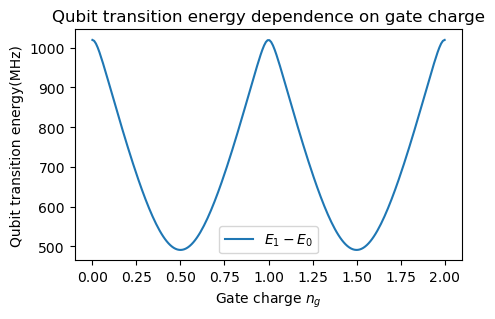

In [5]:
#solve for eigenenergies, and first transition energy
Ec = 230
Ej = 500
N = 10

ng_value = np.linspace(0, 2, 200)
E01_value = []

for ng in ng_value:
    H = get_hamiltonian(Ec, Ej, N, ng)  #hamiltonian
    e_value = H.eigenenergies()  #eigenenergies for hamiltonian
    E01_value.append(e_value[1] - e_value[0])  #first transition energy
    #energy difference between ground and first excited states

plt.figure(figsize=(5,3))
plt.plot(ng_value, E01_value, label = r'$E_1 - E_0$')
plt.xlabel(r'Gate charge $n_g$')
plt.ylabel('Qubit transition energy(MHz)')
plt.title('Qubit transition energy dependence on gate charge')
plt.legend()
plt.show()

In [32]:
#solve for the whole spectrum
def plot_spectrum(ng_val, energy_val, ax=None, ymax=(8000,3)):  #energy_val is the array of eigenenergies
    if ax is None:
        fig, ax = plt.subplots(figsize=(4,5))
        
    l = len(energy_val[0,:])  #length of eigenenergies
    
    for n in range (l):
        ax.plot(ng_val, energy_val[:,n])
        
    ax.set_ylim(-1000, ymax[0])
    ax.set_xlabel(r'$n_g$')
    ax.set_ylabel(r'$E_n$')
    return ax

<Axes: xlabel='$n_g$', ylabel='$E_n$'>

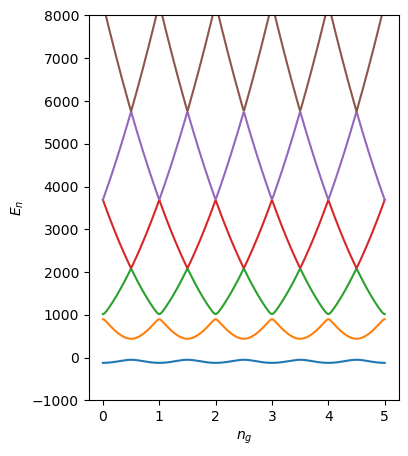

In [33]:
#for the previous case
Ec = 230
Ej = 500
N = 10

#obtain ng values and eigenenergy values
ng_val1 = np.linspace(0, 5, 500)
energy_val1 = np.array([get_hamiltonian(Ec, Ej, N, ng).eigenenergies() for ng in ng_val1])

plot_spectrum(ng_val1, energy_val1)

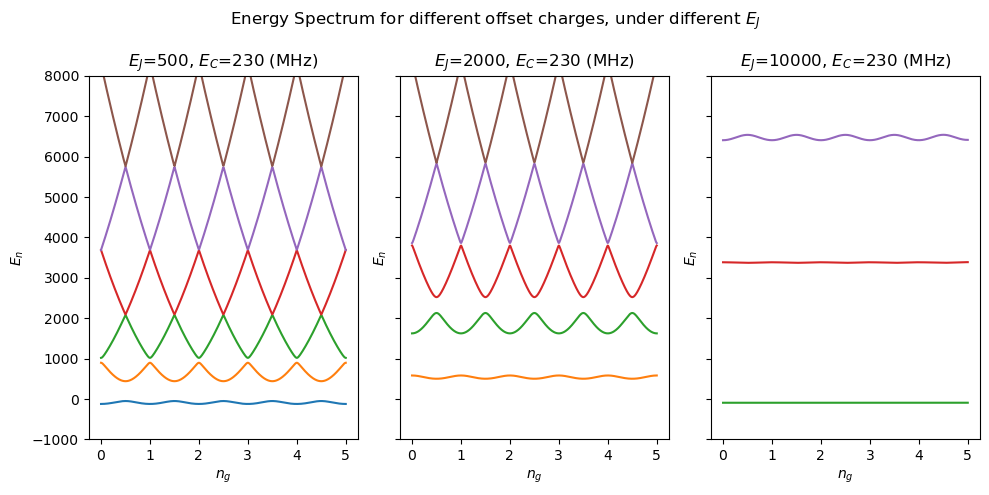

In [36]:
#varying Ej value, increasing Ej value until it hits the transmon regime
Ej2 = 500
Ej3 = 2000
Ej4 = 10000  #transmon regime

ng_val1 = np.linspace(0, 5, 500)
energy_val2 = np.array([get_hamiltonian(Ec, Ej2, N, ng).eigenenergies() for ng in ng_val1])
energy_val3 = np.array([get_hamiltonian(Ec, Ej3, N, ng).eigenenergies() for ng in ng_val1])
energy_val4 = np.array([get_hamiltonian(Ec, Ej4, N, ng).eigenenergies() for ng in ng_val1])

fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
plot_spectrum(ng_val1, energy_val2, ax = axes[0])
axes[0].set_title(f'$E_J$={Ej2}, $E_C$=230 (MHz)')

plot_spectrum(ng_val1, energy_val3, ax = axes[1])
axes[1].set_title(f'$E_J$={Ej3}, $E_C$=230 (MHz)')

plot_spectrum(ng_val1, energy_val4, ax = axes[2])
axes[2].set_title(f'$E_J$={Ej4}, $E_C$=230 (MHz)')

plt.suptitle('Energy Spectrum for different offset charges, under different $E_J$')
plt.tight_layout()

In [59]:
#compare the simulated E_01 with the theoretical expression of sqrt(8*Ec*Ej)
#simulated E_01 at ng=0.5
H1 = get_hamiltonian(Ec, Ej, N, 0.5)  #hamiltonian
e_value1 = H1.eigenenergies()  #eigenenergies for hamiltonian
E_01_experimental = e_value1[1] - e_value1[0]  #experimental first transition energy

E_01_theoretical = np.sqrt(8*Ec*Ej)  #theoretical first transiton energy

print('experimental first transiton energy:', E_01_experimental)
print('theoretical first transition energy:', E_01_theoretical)

experimental first transiton energy: 490.98204516799706
theoretical first transition energy: 959.1663046625439


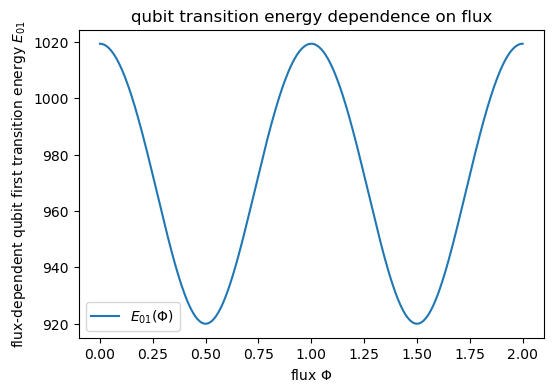

In [37]:
#split junction CPB, where Ej becomes flux-tunable
#flux-tunable qubit
phi_0 = 1.0
phi_value = np.linspace(0,2,400)
E01_phi_value = []

Ec = 230
Ej = 500
N = 10
ng = 0  #offset charge
d = 0  #junction asymmetry

for phi in phi_value:
    cos_term = np.cos(np.pi*phi / phi_0)
    sin_term = np.sin(np.pi*phi / phi_0)
    #flux-dependent Ej, Ej_phi
    Ej_phi = Ej * np.sqrt(cos_term**2 + (d*sin_term)**2)

    #flux-dependent hamiltonian, H_phi
    H_phi_charging = np.diag(4*Ec*(np.arange(-N, N+1)-ng)**2)
    H_phi_tunneling = -0.5*Ej_phi*(np.diag(np.ones(2*N),1) + np.diag(np.ones(2*N), -1))
    H_phi = H_phi_charging + H_phi_tunneling 
    H_phi = Qobj(H_phi)

    #flux-dependent eigenenergies and first transition energy
    e_phi_value = H_phi.eigenenergies()
    E01_phi_value.append(e_phi_value[1] - e_phi_value[0])

E01_phi_value = np.array(E01_phi_value)

#plot
plt.figure(figsize=(6,4))
plt.plot(phi_value, E01_phi_value, label=r'$E_{01}(\Phi)$')
plt.xlabel(r'flux $\Phi$')
plt.ylabel(r'flux-dependent qubit first transition energy $E_{01}$')
plt.title('qubit transition energy dependence on flux')
plt.legend(loc=0)
plt.show()

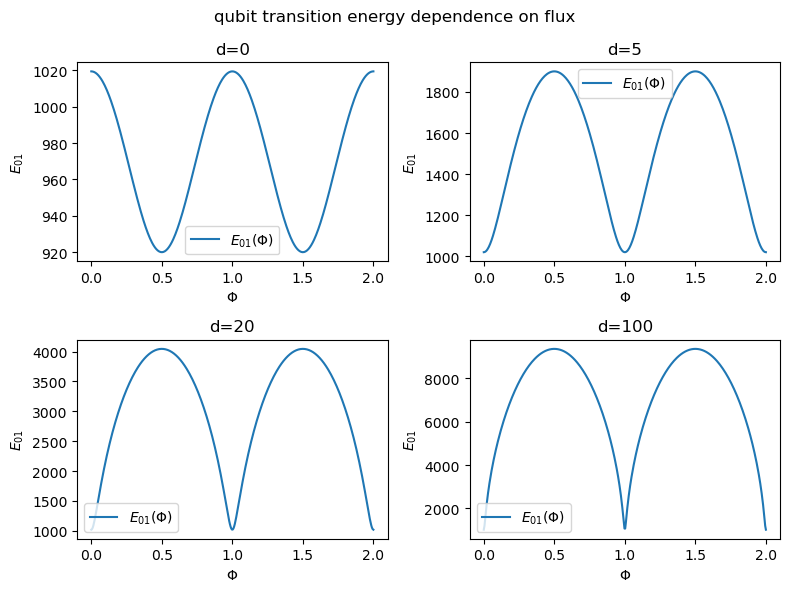

In [42]:
#varing d, the junction asymmetry factor
phi_0 = 1.0
phi_value = np.linspace(0,2,400)

Ec = 230
Ej = 500
N = 10
ng = 0

#hamiltonian dependence on d
def get_flux_hamiltonian(d):
    E01_phi_value = []
    for phi in phi_value:
        cos_term = np.cos(np.pi*phi / phi_0)
        sin_term = np.sin(np.pi*phi / phi_0)
        #flux-dependent Ej, Ej_phi
        Ej_phi = Ej * np.sqrt(cos_term**2 + (d*sin_term)**2)

        #flux-dependent hamiltonian, H_phi
        H_phi_charging = np.diag(4*Ec*(np.arange(-N, N+1)-ng)**2)
        H_phi_tunneling = -0.5*Ej_phi*(np.diag(np.ones(2*N),1) + np.diag(np.ones(2*N), -1))
        H_phi = H_phi_charging + H_phi_tunneling 
        H_phi = Qobj(H_phi)

        #flux-dependent eigenenergies and first transition energy
        e_phi_value = H_phi.eigenenergies()
        E01_phi_value.append(e_phi_value[1] - e_phi_value[0])
    E01_phi_value1 = np.array(E01_phi_value)
    return E01_phi_value1

#d=0, d=5, d=20, d=100 case
E01_phi_value1 = get_flux_hamiltonian(0)
E01_phi_value2 = get_flux_hamiltonian(5)
E01_phi_value3 = get_flux_hamiltonian(20)  
E01_phi_value4 = get_flux_hamiltonian(100)  
E01_list = [E01_phi_value1, E01_phi_value2, E01_phi_value3, E01_phi_value4]
d_list = [0, 5, 20, 100]

#plot
fig, axe = plt.subplots(2, 2, figsize=(8,6))
axe = axe.flatten()
for i in range(0,4):
    axe[i].plot(phi_value, E01_list[i], label=r'$E_{01}(\Phi)$')
    axe[i].legend()
    axe[i].set_title(f'd={d_list[i]}')
    axe[i].set_xlabel(r'$\Phi$')
    axe[i].set_ylabel(r'$E_{01}$')

plt.suptitle('qubit transition energy dependence on flux')
plt.tight_layout()